# Machine Learning Zoomcamp
## Homework 2 - Regression

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler

In [4]:
# Import  and prepare data
data = pd.read_csv('~/python/data/ml_zoomcamp/car_fuel_efficiency_2026.csv')
df = pd.DataFrame(
    data = data,
    columns=[
        'engine_displacement',
        'horsepower',
        'vehicle_weight',
        'model_year',
        'fuel_efficiency_mpg'
    ]
)
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


### EDA
What does the distribution of fuel_efficiency look like?

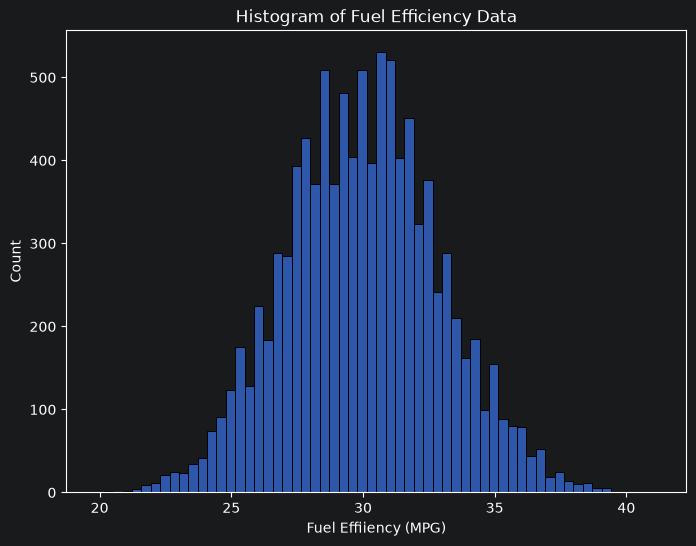

In [5]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,6))

sns.histplot(
    data=df,
    x='fuel_efficiency_mpg',
    ax=ax
)
ax.set_xlabel('Fuel Effiiency (MPG)')
ax.set_title('Histogram of Fuel Efficiency Data')
plt.show()

Fuel efficiency data is roughly normally distributed with no long tails or outliers

### Question 1
There's one column with missing values - what is it?

In [6]:
# count nulls
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

### Question 2
What's the median of 'horsepower'?

In [7]:
# Just get the median
df['horsepower'].median()

254.0

### Question 3
Deal with missing values:
- Replace with 0
- Replace with mean

Compare model performance on both

In [10]:
# Split dataset into features and target
X = df[[
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year'
]]
y = df[['fuel_efficiency_mpg']]

X_train, X, y_train, y = train_test_split(X, y, train_size=0.6, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X, y, train_size=0.5, random_state=42)

# fill null values
fill = X_train['horsepower'].mean()
X_train.fillna(
    value={
        'horsepower': fill
    },
    inplace=True
)
X_val.fillna(
    value={
        'horsepower': fill
    },
    inplace=True
)
X_test.fillna(
    value={
        'horsepower': fill
    },
    inplace=True
)

model = LinearRegression()
model.fit(X_train, y_train)
y_val_pred = model.predict(X_val)
print(np.round(root_mean_squared_error(y_val, y_val_pred), 3))

2.21


In [11]:
# Split dataset into features and target
X = df[[
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year'
]]
y = df[['fuel_efficiency_mpg']]

X_train, X, y_train, y = train_test_split(X, y, train_size=0.6, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X, y, train_size=0.5, random_state=42)

# fill null values
fill = 0
X_train.fillna(
    value={
        'horsepower': fill
    },
    inplace=True
)
X_val.fillna(
    value={
        'horsepower': fill
    },
    inplace=True
)
X_test.fillna(
    value={
        'horsepower': fill
    },
    inplace=True
)

model = LinearRegression()
model.fit(X_train, y_train)
y_val_pred = model.predict(X_val)
print(np.round(root_mean_squared_error(y_val, y_val_pred), 3))

2.213


Imputing missing values with zero works best

### Question 4
Tune the model using regularisation with r values from the list below:

[0, 0.01, 0.1, 1, 5, 10, 100]

In [61]:
# Split dataset into features and target
X = df[[
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year'
]]
y = df[['fuel_efficiency_mpg']]

X_train, X, y_train, y = train_test_split(X, y, train_size=0.6, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X, y, train_size=0.5, random_state=42)

# fill null values
fill = 0
X_train.fillna(
    value={
        'horsepower': fill
    },
    inplace=True
)
X_val.fillna(
    value={
        'horsepower': fill
    },
    inplace=True
)
X_test.fillna(
    value={
        'horsepower': fill
    },
    inplace=True
)


,engine_displacement,horsepower,vehicle_weight,model_year
7072,2300,0.0,4090,1981
6204,2030,232.0,3740,2007
7110,2220,236.0,4160,1989
220,2010,240.0,3720,2018
69,2270,256.0,4000,2001
...,...,...,...,...
1156,2150,249.0,4380,2007
1180,2280,276.0,4610,2014
2697,2440,286.0,4440,2009
9018,2050,246.0,3920,2012


In [32]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

r_vals = [0, 0.01, 0.1, 1, 5, 10, 100]
for r in r_vals:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    y_pred = w0 + X_val.dot(w)
    rmse = np.round(root_mean_squared_error(y_val, y_pred), 4)
    print(f'RMSE with r = {r}: {rmse}')

RMSE with r = 0: 2.2126
RMSE with r = 0.01: 2.2132
RMSE with r = 0.1: 2.2331
RMSE with r = 1: 2.3668
RMSE with r = 5: 2.4304
RMSE with r = 10: 2.441
RMSE with r = 100: 2.4512


r = 0 is the optimal regularisation value

### Question 5
Train model with different random splits for training, validation, and testing

In [51]:
rand_states = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
model = LinearRegression()
errors = []
for state in rand_states:
    # Split dataset into features and target
    X = df[[
        'engine_displacement',
        'horsepower',
        'vehicle_weight',
        'model_year'
    ]]
    y = df[['fuel_efficiency_mpg']]

    X_train, X, y_train, y = train_test_split(X, y, train_size=0.6, random_state=state)
    X_val, X_test, y_val, y_test = train_test_split(X, y, train_size=0.5, random_state=state)

    # fill null values
    fill = 0
    X_train.fillna(
        value={
            'horsepower': fill
        },
        inplace=True
    )
    X_val.fillna(
        value={
            'horsepower': fill
        },
        inplace=True
    )
    X_test.fillna(
        value={
            'horsepower': fill
        },
        inplace=True
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    e = np.round(root_mean_squared_error(y_val, y_pred), 4)
    errors.append(e)
    print(f'Error with random state = {state}: {e}')

Error with random state = 0: 2.1867
Error with random state = 1: 2.2211
Error with random state = 2: 2.2925
Error with random state = 3: 2.2166
Error with random state = 4: 2.2306
Error with random state = 5: 2.2244
Error with random state = 6: 2.1961
Error with random state = 7: 2.2256
Error with random state = 8: 2.1842
Error with random state = 9: 2.1953


In [54]:
# standard deviation of errors
std = np.round(np.std(errors), 3)
std

0.03

### Question 6
Train the model with random state 9 and r = 0.001
Combine training and validation sets
Calculate rmse

In [56]:
# Split dataset into features and target
X = df[[
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year'
]]
y = df[['fuel_efficiency_mpg']]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.6, random_state=9)

# fill null values
fill = 0
X_train.fillna(
    value={
        'horsepower': fill
    },
    inplace=True
)
X_test.fillna(
    value={
        'horsepower': fill
    },
    inplace=True
)


,engine_displacement,horsepower,vehicle_weight,model_year
3644,2320,246.0,4100,2014
9184,2230,252.0,4250,1998
520,2700,276.0,4490,2008
5685,2220,269.0,4060,2004
2401,2370,0.0,4690,1979
...,...,...,...,...
6871,2180,246.0,4020,1996
8206,2260,255.0,3880,2004
821,2400,293.0,4500,2016
288,2570,275.0,4520,1995


In [60]:
ridge_model = Ridge(alpha=0.001)
ridge_model.fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)
error = root_mean_squared_error(y_test, y_pred)
print(error)

2.197421322032585
